# Harry Potter network analysis with NetworkX

This notebook loads a CSV edge list with columns:

- `source`
- `target`
- `weight`

It then builds a weighted network in **NetworkX** and performs some basic analysis:

- quick data checks
- graph summary statistics
- degree and weighted degree
- centrality measures
- connected components
- community detection
- basic visualizations

Update the `CSV_PATH` below to point to your file.


In [ ]:
# Optional: install packages if needed
# Uncomment and run if your environment does not already have these installed.

# %pip install pandas networkx matplotlib

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.grid"] = True

In [2]:
# Path to your edge-list CSV
CSV_PATH = "hp_network.csv"  # change this to your actual file name/path

# If your CSV uses a different separator, set sep accordingly, e.g. sep=';'
df = pd.read_csv(CSV_PATH)

required_cols = {"source", "target", "weight"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df.head()

,source,target,weight
0,Harry Potter,Ron Weasley,25
1,Harry Potter,Hermione Granger,25
2,Harry Potter,Albus Dumbledore,12
3,Harry Potter,Rubeus Hagrid,14
4,Harry Potter,Severus Snape,11


## 1. Basic data checks

In [3]:
print("Rows:", len(df))
print("Unique source nodes:", df["source"].nunique())
print("Unique target nodes:", df["target"].nunique())

all_nodes = pd.Index(df["source"]).append(pd.Index(df["target"]))
print("Total unique nodes:", all_nodes.nunique())

print("\nColumn dtypes:")
print(df.dtypes)

print("\nMissing values:")
print(df[["source", "target", "weight"]].isna().sum())

print("\nDuplicate edges (exact duplicate rows):", df.duplicated().sum())

Rows: 56
Unique source nodes: 18
Unique target nodes: 22
Total unique nodes: 25

Column dtypes:
source    object
target    object
weight     int64
dtype: object

Missing values:
source    0
target    0
weight    0
dtype: int64

Duplicate edges (exact duplicate rows): 0


In [4]:
# Clean up obvious issues
clean_df = df.dropna(subset=["source", "target", "weight"]).copy()

# Standardize node labels a bit
clean_df["source"] = clean_df["source"].astype(str).str.strip()
clean_df["target"] = clean_df["target"].astype(str).str.strip()
clean_df["weight"] = pd.to_numeric(clean_df["weight"], errors="coerce")

clean_df = clean_df.dropna(subset=["weight"])

print("Rows after cleanup:", len(clean_df))
clean_df.head()

Rows after cleanup: 56


,source,target,weight
0,Harry Potter,Ron Weasley,25
1,Harry Potter,Hermione Granger,25
2,Harry Potter,Albus Dumbledore,12
3,Harry Potter,Rubeus Hagrid,14
4,Harry Potter,Severus Snape,11


## 2. Build the graph

This creates an **undirected weighted graph**. If your network should be directional, replace `nx.Graph()` with `nx.DiGraph()`.


In [5]:
G = nx.Graph()

for _, row in clean_df.iterrows():
    s, t, w = row["source"], row["target"], row["weight"]

    # Combine repeated edges by summing weights
    if G.has_edge(s, t):
        G[s][t]["weight"] += w
    else:
        G.add_edge(s, t, weight=w)

print(nx.info(G) if hasattr(nx, "info") else f"Graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Graph with 25 nodes and 55 edges


/var/folders/tb/qhy13fz56xqbr70dk7mghy840000gp/T/ipykernel_40940/3393976320.py:12: DeprecationWarning: info is deprecated and will be removed in version 3.0.

  print(nx.info(G) if hasattr(nx, "info") else f"Graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")


## 3. Basic graph statistics

In [6]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

is_connected = nx.is_connected(G) if num_nodes > 0 else False
components = list(nx.connected_components(G)) if num_nodes > 0 else []

avg_degree = sum(dict(G.degree()).values()) / num_nodes if num_nodes else 0
avg_weighted_degree = sum(dict(G.degree(weight="weight")).values()) / num_nodes if num_nodes else 0

stats = {
    "nodes": num_nodes,
    "edges": num_edges,
    "density": density,
    "is_connected": is_connected,
    "connected_components": len(components),
    "average_degree": avg_degree,
    "average_weighted_degree": avg_weighted_degree,
}

stats

{'nodes': 25,
 'edges': 55,
 'density': 0.18333333333333332,
 'is_connected': True,
 'connected_components': 1,
 'average_degree': 4.4,
 'average_weighted_degree': 38.64}

In [7]:
if components:
    component_sizes = sorted([len(c) for c in components], reverse=True)
    print("Largest component sizes:", component_sizes[:10])

Largest component sizes: [25]


## 4. Top characters by degree and weighted degree

In [8]:
degree_df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree": [G.degree(n) for n in G.nodes()],
    "weighted_degree": [G.degree(n, weight="weight") for n in G.nodes()],
}).sort_values(["weighted_degree", "degree"], ascending=False)

degree_df.head(15)

,node,degree,weighted_degree
0,Harry Potter,17,181
1,Ron Weasley,9,100
2,Hermione Granger,8,90
3,Albus Dumbledore,9,86
11,Voldemort,7,62
5,Severus Snape,6,51
4,Rubeus Hagrid,4,44
12,Minerva McGonagall,5,36
6,Draco Malfoy,5,34
7,Ginny Weasley,4,32


## 5. Centrality measures

These often help identify the most important or influential characters in the network.


In [9]:
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G, weight="weight")
closeness_centrality = nx.closeness_centrality(G)

try:
    eigenvector_centrality = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)
except Exception as e:
    print("Eigenvector centrality failed:", e)
    eigenvector_centrality = {n: None for n in G.nodes()}

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "degree_centrality": [degree_centrality[n] for n in G.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in G.nodes()],
    "closeness_centrality": [closeness_centrality[n] for n in G.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[n] for n in G.nodes()],
}).sort_values("betweenness_centrality", ascending=False)

centrality_df.head(15)

,node,degree_centrality,betweenness_centrality,closeness_centrality,eigenvector_centrality
0,Harry Potter,0.708333,0.346014,0.774194,0.551030
1,Ron Weasley,0.375000,0.317029,0.571429,0.399917
12,Minerva McGonagall,0.208333,0.317029,0.521739,0.184287
5,Severus Snape,0.250000,0.153986,0.521739,0.187867
6,Draco Malfoy,0.208333,0.125000,0.510638,0.111831
3,Albus Dumbledore,0.375000,0.103261,0.558140,0.296709
9,Remus Lupin,0.208333,0.085145,0.489796,0.098701
2,Hermione Granger,0.333333,0.077899,0.558140,0.422110
11,Voldemort,0.291667,0.038043,0.533333,0.184584
21,Peter Pettigrew,0.125000,0.019928,0.375000,0.029397


## 6. Inspect the largest connected component

Some algorithms and visualizations are easier to interpret on the largest component.


In [10]:
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc_nodes).copy()

print(f"Largest connected component: {G_lcc.number_of_nodes()} nodes, {G_lcc.number_of_edges()} edges")

Largest connected component: 25 nodes, 55 edges


## 7. Community detection

This uses NetworkX's greedy modularity communities on the largest connected component.


In [11]:
from networkx.algorithms.community import greedy_modularity_communities

communities = list(greedy_modularity_communities(G_lcc, weight="weight"))
community_sizes = sorted([len(c) for c in communities], reverse=True)

print("Number of communities:", len(communities))
print("Largest community sizes:", community_sizes[:10])

Number of communities: 6
Largest community sizes: [9, 5, 4, 3, 2, 2]


In [12]:
# Map node -> community id
community_map = {}
for i, comm in enumerate(communities):
    for node in comm:
        community_map[node] = i

community_df = pd.DataFrame({
    "node": list(community_map.keys()),
    "community": list(community_map.values())
}).merge(degree_df, on="node", how="left").sort_values(["community", "weighted_degree"], ascending=[True, False])

community_df.head(20)

,node,community,degree,weighted_degree
8,Harry Potter,0,17,181
7,Ron Weasley,0,9,100
4,Hermione Granger,0,8,90
2,Ginny Weasley,0,4,32
0,Luna Lovegood,0,4,24
3,Neville Longbottom,0,3,21
6,Dobby,0,1,6
1,Cedric Diggory,0,1,5
5,Cho Chang,0,1,4
13,Voldemort,1,7,62


## 8. Plot distributions

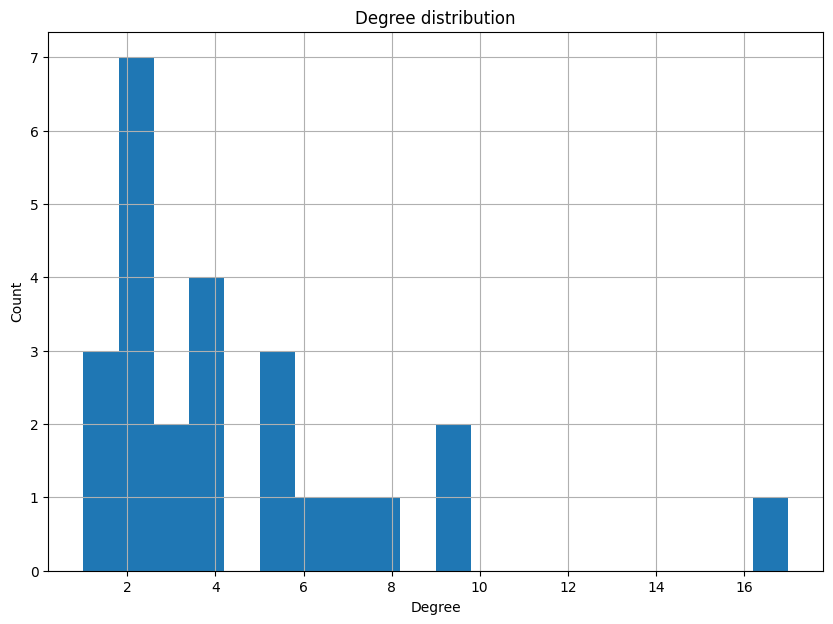

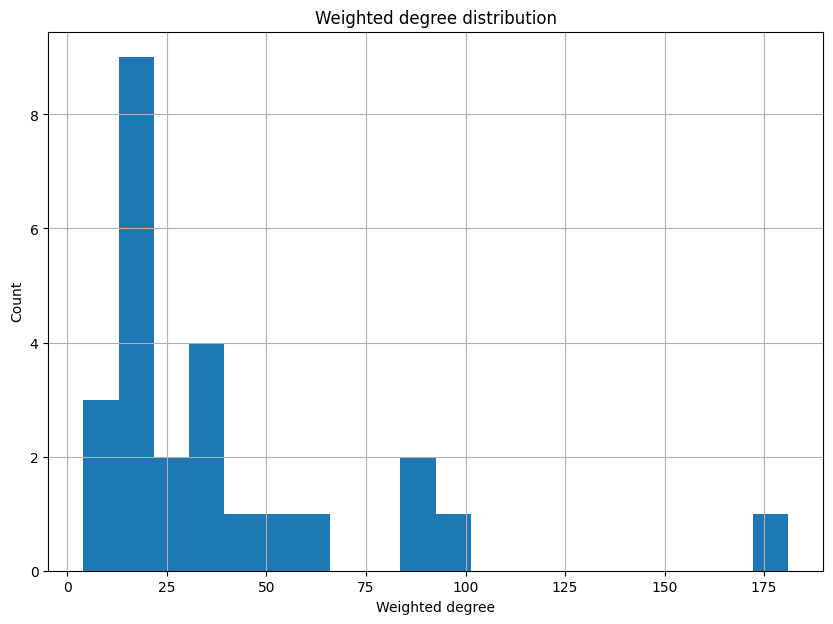

In [13]:
plt.figure()
degree_df["degree"].hist(bins=20)
plt.title("Degree distribution")
plt.xlabel("Degree")
plt.ylabel("Count")
plt.show()

plt.figure()
degree_df["weighted_degree"].hist(bins=20)
plt.title("Weighted degree distribution")
plt.xlabel("Weighted degree")
plt.ylabel("Count")
plt.show()

## 9. Visualize the network

For readability, this plots the largest connected component and labels only the top nodes by weighted degree.


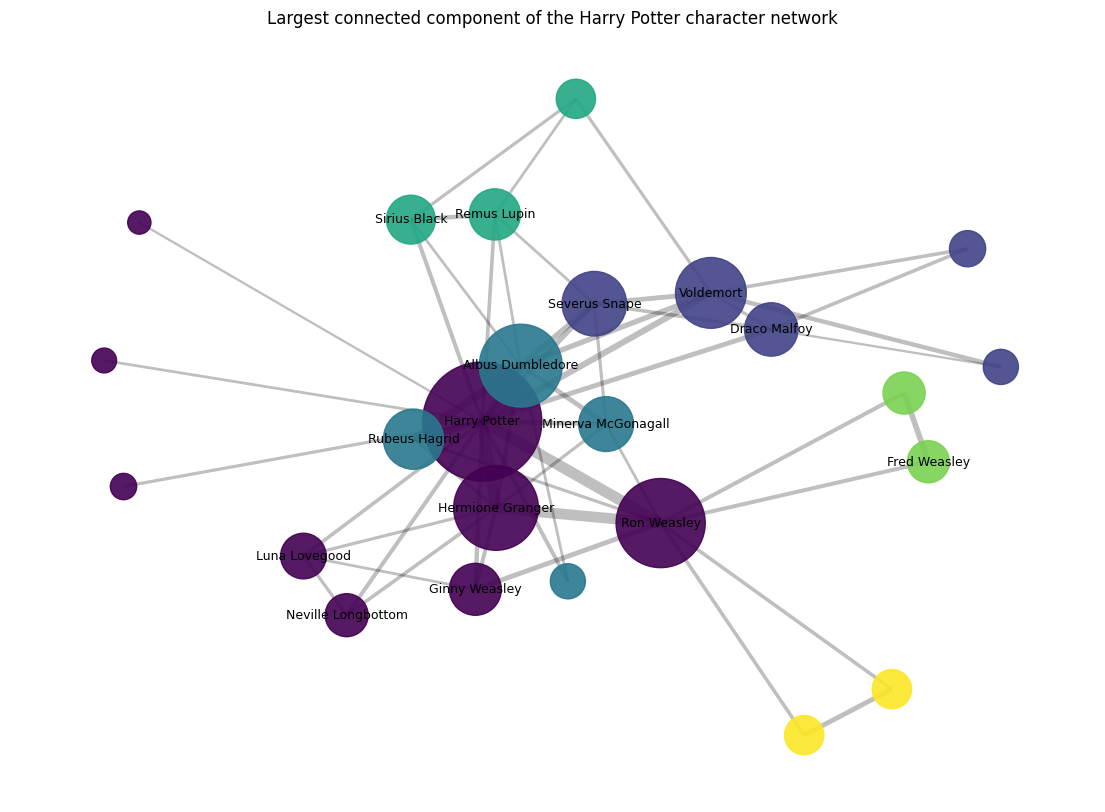

In [14]:
top_nodes = set(degree_df.head(15)["node"])
pos = nx.spring_layout(G_lcc, seed=42, weight="weight")

node_sizes = [120 + 40 * G_lcc.degree(n, weight="weight") for n in G_lcc.nodes()]
node_colors = [community_map.get(n, 0) for n in G_lcc.nodes()]
edge_widths = [0.5 + 0.3 * d.get("weight", 1) for _, _, d in G_lcc.edges(data=True)]

plt.figure(figsize=(14, 10))
nx.draw_networkx_edges(G_lcc, pos, alpha=0.25, width=edge_widths)
nx.draw_networkx_nodes(G_lcc, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)

labels = {n: n for n in G_lcc.nodes() if n in top_nodes}
nx.draw_networkx_labels(G_lcc, pos, labels=labels, font_size=9)

plt.title("Largest connected component of the Harry Potter character network")
plt.axis("off")
plt.savefig("xxx.pdf")
plt.show()

## 10. Save results

This exports key summary tables for later use.


In [ ]:
degree_df.to_csv("hp_degree_metrics.csv", index=False)
centrality_df.to_csv("hp_centrality_metrics.csv", index=False)
community_df.to_csv("hp_community_assignments.csv", index=False)

print("Saved:")
print("- hp_degree_metrics.csv")
print("- hp_centrality_metrics.csv")
print("- hp_community_assignments.csv")

## 11. Ideas for extending the analysis

A few useful next steps:

- compare networks across different books
- build a directed graph if interactions are directional
- filter low-weight edges to reduce noise
- examine shortest paths between key characters
- compute assortativity or clustering coefficients
- color nodes by house, family, or role if metadata is available
